<a href="https://colab.research.google.com/github/nikhilreddi02/MLClassificationProject/blob/main/MLClassifiactionProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
np.random.seed(42)
n = 1000
df = pd.DataFrame({
    "Study_hours" : np.random.uniform(1,10,n),
    "attendence" : np.random.uniform(50,100,n),
    "previous_score": np.random.uniform(40,100,n),
    "sleep_hours" : np.random.uniform(4,9,n),
    "assignments_completed" : np.random.randint(0,11,n),
    "internet_acces" : np.random.choice(["yes","no"],n),
    "extracurricular":np.random.choice(["yes","no"],n),
    })

In [ ]:
score = (
    df['Study_hours'] * 5
    +df['attendence'] * 0.4
    +df['previous_score'] * 0.3
    +df['assignments_completed'] * 2
    +np.random.normal(0,10,n)
)
df["pass"] = (score >= 75).astype(int)

In [ ]:
df

,Study_hours,attendence,previous_score,sleep_hours,assignments_completed,internet_acces,extracurricular,pass
0,4.370861,59.256646,55.702341,7.363515,9,yes,yes,0
1,9.556429,77.095047,54.818728,7.983407,4,yes,yes,1
2,7.587945,93.647292,94.375275,5.252339,4,yes,no,1
3,6.387926,86.611244,54.972772,7.124370,10,yes,yes,1
4,2.404168,90.328057,56.316984,6.858730,6,yes,yes,0
...,...,...,...,...,...,...,...,...
995,1.824239,82.847758,91.917746,6.210535,6,no,yes,1
996,9.255822,97.830731,49.436392,5.672006,5,yes,no,1
997,2.231368,53.447901,58.587272,5.972862,10,no,no,0
998,9.552136,52.852736,57.402732,6.649703,0,no,no,1


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

In [ ]:
df.isnull().sum()

,0
Study_hours,0
attendence,0
previous_score,0
sleep_hours,0
assignments_completed,0
internet_acces,0
extracurricular,0
pass,0


In [ ]:
df['pass'].value_counts()

,count
pass,
1,742
0,258


In [ ]:
X = df.drop('pass',axis=1)
y = df['pass']

In [ ]:
X

,Study_hours,attendence,previous_score,sleep_hours,assignments_completed,internet_acces,extracurricular
0,4.370861,59.256646,55.702341,7.363515,9,yes,yes
1,9.556429,77.095047,54.818728,7.983407,4,yes,yes
2,7.587945,93.647292,94.375275,5.252339,4,yes,no
3,6.387926,86.611244,54.972772,7.124370,10,yes,yes
4,2.404168,90.328057,56.316984,6.858730,6,yes,yes
...,...,...,...,...,...,...,...
995,1.824239,82.847758,91.917746,6.210535,6,no,yes
996,9.255822,97.830731,49.436392,5.672006,5,yes,no
997,2.231368,53.447901,58.587272,5.972862,10,no,no
998,9.552136,52.852736,57.402732,6.649703,0,no,no


In [ ]:
X_train,x_test,Y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
numeric_features = X.select_dtypes(include=['int64','float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

In [ ]:
print(numeric_features)
print(categorical_features)

Index(['Study_hours', 'attendence', 'previous_score', 'sleep_hours',
       'assignments_completed'],
      dtype='object')
Index(['internet_acces', 'extracurricular'], dtype='object')


In [ ]:
numeric_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='mean')),
    ('scaler',StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:
preprocessor =ColumnTransformer(transformers=[
    ('numeric',numeric_pipeline,numeric_features),
    ('categorical',categorical_pipeline,categorical_features)
])

In [ ]:
model = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('classifier',LogisticRegression())
])

In [ ]:
model.fit(X_train,Y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Study_hours', 'attendence', 'previous_score', 'sleep_hours',
       'assignments_completed'],
      dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['internet_acces', 'extracurricular'], dtype='object'))])),
                ('classifier', LogisticRegression())])

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

0.89


In [ ]:
precision = precision_score(y_test,y_pred)
print(precision)

0.9256756756756757


In [ ]:
recall = recall_score(y_test,y_pred)
print(recall)

0.9256756756756757


In [ ]:
f1 = f1_score(y_test,y_pred)
print(f1)

0.9256756756756757


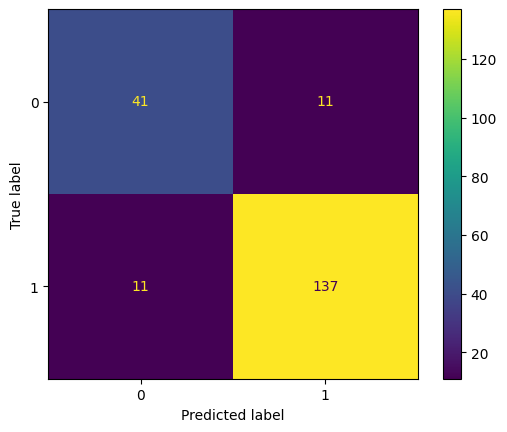

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model.classes_)
disp.plot()

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.79      0.79      0.79        52
           1       0.93      0.93      0.93       148

    accuracy                           0.89       200
   macro avg       0.86      0.86      0.86       200
weighted avg       0.89      0.89      0.89       200



In [ ]:
y_pred_proba = model.predict_proba(x_test)[:,1]
roc_auc = roc_auc_score(y_test,y_pred_proba)
print(roc_auc)

0.9186590436590437


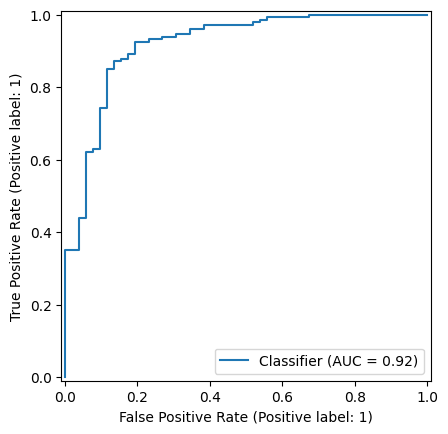

In [ ]:
RocCurveDisplay.from_predictions(y_test,y_pred_proba)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_model = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('classifier',RandomForestClassifier())
])

In [ ]:
rf_model.fit(X_train,Y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Study_hours', 'attendence', 'previous_score', 'sleep_hours',
       'assignments_completed'],
      dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['internet_acces', 'extracurricular'], dtype='object'))])),
                ('classifier', RandomForestClassifier())])

In [ ]:
rf_pred = rf_model.predict(x_test)

In [ ]:
print("Accuracy:",
      accuracy_score(y_test, rf_pred))

print("Precision:",
      precision_score(y_test, rf_pred))

print("Recall:",
      recall_score(y_test, rf_pred))

print("F1:",
      f1_score(y_test, rf_pred))

Accuracy: 0.86
Precision: 0.8947368421052632
Recall: 0.918918918918919
F1: 0.9066666666666666


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1": [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred)
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall        F1
0  Logistic Regression      0.89   0.925676  0.925676  0.925676
1        Random Forest      0.86   0.894737  0.918919  0.906667


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

In [ ]:
print("CV scores:",scores)
print("Mean CV score:",scores.mean())

CV scores: [0.89  0.89  0.86  0.845 0.86 ]
Mean CV score: 0.8690000000000001


In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [5, 10, None],
    "classifier__min_samples_split": [2, 5]
}

In [ ]:
grid = GridSearchCV(
    rf_model,
    params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, Y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['Study_hours', 'attendence', 'previous_score', 'sleep_hours',
       'assignments_completed'],
      dtype='object')),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         Index(['internet_acces', 'extracurricular'], dtype='object'))])),
                                       ('classifier',
                                        RandomForestClassifier())]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [5, 10, None],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [100, 200]},
             scoring='f1')

In [ ]:
print(grid.best_params_)

{'classifier__max_depth': 5, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}


In [ ]:
print(grid.best_score_)

0.9121224099898659


In [ ]:
final_model = grid.best_estimator_

final_pred = final_model.predict(x_test)

print(classification_report(
    y_test,
    final_pred
))

              precision    recall  f1-score   support

           0       0.80      0.63      0.71        52
           1       0.88      0.95      0.91       148

    accuracy                           0.86       200
   macro avg       0.84      0.79      0.81       200
weighted avg       0.86      0.86      0.86       200

